In [1]:
'''
author: Yike Xie
data: 4/26/2025
content: Cell size analysis based on a 10X cell cycle dataset
'''

'\nauthor: Yike Xie\ndata: 4/26/2025\ncontent: Integration of SpectralSeq data and other MCF-7 scRNA-Seq\n'

In [1]:
import os
import sys
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import skimage

import scanpy as sc
import anndata
import pickle

import cv2

import harmonypy as hm

# create other MCF-7 datasets

In [40]:
# GSE144320
path = '/home/yike/phd/cancer_cells_img_seq/docs/manuscripts/Genome_research_202409/2nd_review/other_MCF7_datasets/GSE144320_10X_MCF_WT_ESR1_mutation'

data = pd.read_csv(os.path.join(path, 'GSM4285803_scRNA_RawCounts.csv'), index_col=0)
metadata = pd.read_csv(os.path.join(path, 'GSM4285803_scRNA_metaInfo.csv'), index_col=0)

MCF7_data = data.loc[metadata[metadata['CellType'] == 'MCF7'].index]
MCF7_metadata = metadata[metadata['CellType'] == 'MCF7']

cc_adata = anndata.AnnData(
    X=MCF7_data.values,
    var=pd.DataFrame([], index=MCF7_data.columns),
    obs=MCF7_metadata[['phase']],
)

cc_adata.obs['Lib_prep'] = '10X'
cc_adata.obs['GEO'] = 'GSE144320'

# Leverage the GSE144320 dataset (10X cell cycle study)

| Phase    | Meaning                                                                   | Expected Cell Size  |
|----------|---------------------------------------------------------------------------|---------------------|
| G2/M     | Cells have replicated DNA and are preparing for or undergoing mitosis     | 🔴 Largest           |
| G2       | Post-DNA replication, just before mitosis (similar to G2/M)               | 🔴 Large             |
| S phase  | DNA synthesis is actively occurring                                       | 🟡 Medium            |
| G1/S     | Transition from G1 to S phase, checkpoint activation                      | 🟢 Medium-small      |
| M/G1     | Post-mitosis or early G1 transition                                       | 🟠 Medium-small      |

In [48]:
sc.pp.normalize_total(cc_adata, target_sum=1e4)

/home/yike/.conda/envs/scanpy/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [49]:
cc_adata.obs['area'] = np.nan
for i, phase in enumerate(['M/G1', 'G1/S', 'S phase', 'G2', 'G2/M']):
    cc_adata.obs.loc[cc_adata.obs['phase'] == phase, 'area'] = i + 1

In [50]:
def get_correlation(adata_s, feas):
    #corr = dsim.correlation.correlate_features_phenotypes(feas, fillna=0)##
    exp = adata_s.X.T
    phe = adata_s.obs[feas].fillna(0)

    x = exp #(39466, 10)
    y = phe.values.T #(2, 10)

    from scipy.stats import rankdata

    xw = np.zeros_like(x, float)
    for ii, xi in enumerate(x):
        xw[ii] = rankdata(xi, method='average')
    yw = np.zeros_like(y, float)
    for ii, yi in enumerate(y):
        yw[ii] = rankdata(yi, method='average')

    xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T
    yw = ((yw.T - yw.mean(axis=1)) / yw.std(axis=1)).T
    n = xw.shape[1]
    r = np.dot(xw, yw.T) / n

    corr = pd.DataFrame(
                    data=r,
                    index=adata_s.var_names,
                    columns=phe.columns,
                    dtype=float)

    return corr

In [51]:
feas = ['area']
corr = get_correlation(cc_adata, feas)

corr['Frac'] = 100 * (cc_adata[:, corr.index].X > 0).sum(axis=0) / cc_adata.obs.shape[0]
corr['Number'] = (cc_adata[:, corr.index].X > 0).sum(axis=0)

/tmp/ipykernel_27219/1434950178.py:18: RuntimeWarning: invalid value encountered in divide
  xw = ((xw.T - xw.mean(axis=1)) / xw.std(axis=1)).T


In [56]:
import gseapy as gp
from gseapy.plot import barplot

def pathway_df(gene_list):    
    pthw = gp.enrichr(gene_list=gene_list,
                         gene_sets=['GO_Biological_Process_2021'],
                         cutoff = False).res2d

    pthw_plot = pthw[:10]
    pthw_plot['-log10(P-value)'] = -np.log10(pthw_plot['P-value'])
    
    return pthw_plot

In [57]:
n = 300
neg_list = corr[corr['Number'] >= 10]['area'].sort_values()[:n].index.tolist()
pos_list = corr[corr['Number'] >= 10]['area'].sort_values()[-n:].index.tolist()

gene_list = neg_list + pos_list

# pathway analysis
pt_df_n = pathway_df(neg_list)
pt_df_p = pathway_df(pos_list)
pthw_plot = pd.concat([pt_df_p[:5], pt_df_n[:5]])

/tmp/ipykernel_27219/2235773686.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pthw_plot['-log10(P-value)'] = -np.log10(pthw_plot['P-value'])
/tmp/ipykernel_27219/2235773686.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pthw_plot['-log10(P-value)'] = -np.log10(pthw_plot['P-value'])


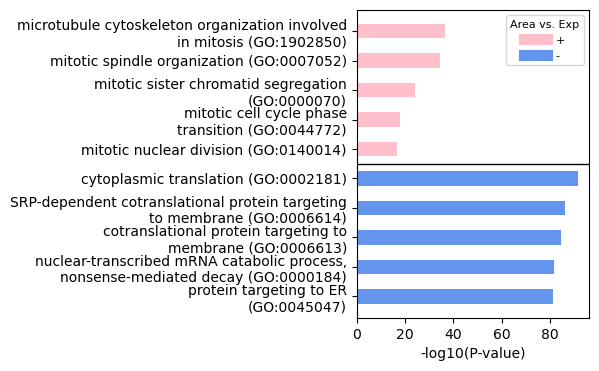

In [59]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=[3, 4])
rcParams['pdf.fonttype'] = 42
rcParams['font.size'] = 8

ax.barh(range(10), pthw_plot['-log10(P-value)'][::-1], 
        height=0.5, color=['cornflowerblue'] * 5 + ['pink'] * 5)
ax.set_yticks(range(10))
yticklabels = []
for i in pthw_plot['Term'][::-1]:
    if len(i.split(' ')) > 4:
        yticklabels.append(' '.join(i.split(' ')[:4]) + '\n' + ' '.join(i.split(' ')[4:]))
    else:
        yticklabels.append(i)
ax.set_yticklabels(yticklabels)

ax.axhline(4.5, c='k', lw=1)
handles = [Line2D([], [], lw=8, c='pink'),
           Line2D([], [], lw=8, c='cornflowerblue')]
ax.legend(handles=handles, labels=['+', '-'], title='Area vs. Exp', loc='best', fontsize=8)

ax.set_xlabel('-log10(P-value)')
fig.savefig('/home/yike/phd/cancer_cells_img_seq/docs/manuscripts/Genome_research_202409/2nd_review/' + '10x_cell_cycle_300_genes_area_pathway.pdf', 
            dpi=300, bbox_inches='tight')